# Starting from an all-electron ground state

An all-electron code and a pseudopotential code do not converge to the same
density. Inside the core region they cannot: one carries the nuclear cusp and
every electron the atom has, the other carries a smooth valence density and a
potential built to reproduce the same scattering outside a cutoff radius. Outside
that radius they should agree, and how well they do is a statement about the
pseudopotential rather than about either code.

This notebook reads a converged ground state from Elk, an all-electron LAPW code,
puts its density on this run's grid, and starts a calculation from it. The cell is
simple cubic hydrogen at 3.0 bohr, which is the one element where there is no core
to leave behind.

Beyond 0.4 bohr from the nucleus the two densities agree to within **3 per
cent**. At the nucleus the pseudo density is **38 per cent** lower.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

calc = Calculator.from_file('../tests/data/elk/h_sc/scf.in',
                            pseudo_dir='../tests/data/pseudo')
seed = calc.get_elk_seed('../tests/data/elk/h_sc')
result = calc.get_scf(starting_density=seed)
print(f'started from an all-electron density')
print(f'total energy   {result.total_energy:.12f} Ry')
print(f'iterations     {result.iterations}')

started from an all-electron density
total energy   -1.080181442650 Ry
iterations     4


## What was read

An all-electron code stores a density in two pieces that meet at a sharp sphere
around each nucleus. Inside the sphere it is an expansion in real spherical
harmonics on a logarithmic radial mesh, fine enough near the origin to resolve a
cusp:

$$\rho(\mathbf r) = \sum_{lm} f_{lm}(r)\,R_{lm}(\hat{\mathbf r}),
\qquad |\mathbf r - \mathbf R_a| < r_a .$$

Outside every sphere it is an ordinary Fourier series on a uniform grid. Putting
such a density on a plane-wave grid therefore means asking, for each grid point,
which region it is in, and then either interpolating radially or summing the
series.

The two charges are worth printing because they are computed in completely
unrelated ways: a spline quadrature on the radial mesh against a Fourier
integral on the uniform one. Both agree with what the reference run printed to
every digit it printed.

In [2]:
from defumat.io import ElkState

state = ElkState.read('../tests/data/elk/h_sc')
inside = float(state.muffin_tin_charges().sum())
outside = state.interstitial_charge()
print(f'sphere radius       {state.rmt[0]:.3f} bohr')
print(f'charge inside       {inside:.10f}   (reference 0.6125761996)')
print(f'charge outside      {outside:.10f}   (reference 0.3874238004)')
print(f'total               {inside + outside:.10f}')

sphere radius       1.400 bohr
charge inside       0.6125761996   (reference 0.6125761996)
charge outside      0.3874238004   (reference 0.3874238004)
total               1.0000000000


## Where the two descriptions must differ

The pseudopotential replaces the true potential inside a cutoff radius with
something smooth that scatters the same way outside it. So the valence density it
produces has no business matching the all-electron one inside that radius, and
every reason to match it outside.

That is exactly what the line through the nucleus shows.

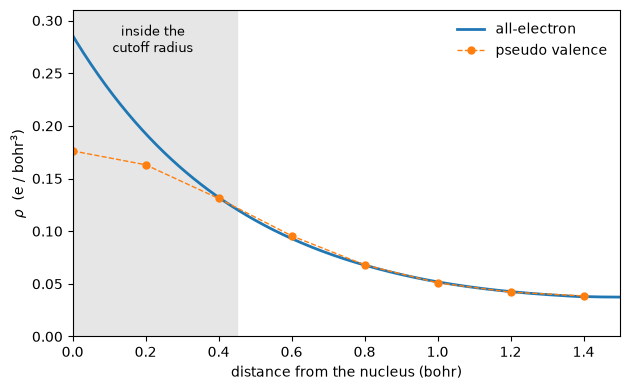

In [3]:
x = np.linspace(0.0, 1.5, 300)
allelectron = state.evaluate_at(np.stack([x / 3.0, 0 * x, 0 * x], axis=1))

rho = np.asarray(result.density)[0][:, 0, 0]
grid = np.arange(len(rho)) * 3.0 / len(rho)
half = grid <= 1.5

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.axvspan(0.0, 0.45, color='0.90')
ax.text(0.22, 0.27, 'inside the\ncutoff radius', ha='center', fontsize=9)
ax.plot(x, allelectron, lw=2, label='all-electron')
ax.plot(grid[half], rho[half], 'o--', ms=5, lw=1, label='pseudo valence')
ax.set_xlabel('distance from the nucleus (bohr)')
ax.set_ylabel(r'$\rho$  (e / bohr$^3$)')
ax.set_xlim(0.0, 1.5)
ax.set_ylim(0.0, 0.31)
ax.legend(frameon=False)
fig.tight_layout()

The cusp is a real feature of the all-electron density and it survives the
transfer intact, because the muffin-tin part is written onto the grid point by
point and never passes through a Fourier truncation. Nothing about the sharp peak
at the origin is lost or smeared.

Beyond about 0.4 bohr the two curves lie on top of each other to within a few
per cent, which is the pseudopotential doing its job. What is left there is a
real difference between the two calculations rather than a transfer error: they
are two converged ground states of the same crystal, computed in bases with
almost nothing in common.

## Does starting from it help?

The reason to want an all-electron starting guess is that it might be closer to
the answer than a superposition of isolated atomic charges, and so save
iterations. Here it does not.

In [4]:
plain = Calculator.from_file('../tests/data/elk/h_sc/scf.in',
                             pseudo_dir='../tests/data/pseudo')
atomic = plain.get_scf()

print(f'{"started from":<24}{"energy (Ry)":>18}{"iterations":>13}')
print(f'{"atomic charges":<24}{atomic.total_energy:>18.12f}{atomic.iterations:>13d}')
print(f'{"all-electron density":<24}{result.total_energy:>18.12f}{result.iterations:>13d}')
print(f'\nthe two answers differ by {abs(result.total_energy - atomic.total_energy):.1e} Ry')

started from                   energy (Ry)   iterations
atomic charges             -1.080181442650            4
all-electron density       -1.080181442650            4

the two answers differ by 6.4e-14 Ry


Four iterations either way, and the same total energy to fourteen decimal
places. At a lower cutoff the transferred density costs one iteration *more*.

That is the honest result and it has a physical reason. For a hydrogen atom a
superposition of atomic charges is already almost the answer, and the part of the
all-electron density that differs from it is the cusp, which sits inside the
cutoff radius, which is precisely the region where the pseudo density is supposed
to look nothing like it. The starting guess is being handed a feature the answer
does not want.

What the transfer is worth is the bridge itself: an all-electron ground state,
computed in a completely different basis, can be brought here and compared point
by point. The agreement in the figure above is a measurement of the
pseudopotential, and nothing in a plane-wave code alone can make it.

An element with a core is a different problem. The muffin-tin density there
includes the core states, and there is nothing in the file that says which part of
the charge is which, so a run whose valence electron count is far from what the
state integrates to is refused rather than scaled to fit. A spin-polarized state,
a spin spiral and a Hubbard-corrected one are refused too: each carries a further
field that a charge density alone does not describe.

*The checks behind the numbers quoted here live in
`tests/unit/test_elk_reader.py` and `tests/regression/test_elk_seed.py`.*